# Проект. Разработка A/B-тестирования и анализ результатов

+ Автор: *Наталья Мартынова*
+ Дата: *декабрь 2025 г.*

Заказчиком выступает компания, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. 

Нас просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

*Цель* - c помощью A/B-тестирования выяснить, повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как, и дать рекомендации, стоит ли внедрять нововведение в приложение.

*Задачи:* 

- рассчитать параметры теста; 
- оценить корректность его проведения;
- проанализировать результаты эксперимента;
- сформулировать вывод и рекомендации.

## Описание данных

Будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Прочитаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

- Выведем на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

sessions_history = pd.read_csv('.../sessions_project_history.csv')

sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [2]:
# Выведем общую информацию о загруженной таблице
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


В датафрейме 435924 строки и 10 столбцов. 

Пропусков в столбцах нет. 

Столбцы с идентификаторами пользователей и сессий, датами и с категориальными признаками (регион, тип устройства) загрузились в тип object. 

Числовые данные (номер сессии и число просмотренных страниц) и бинарный признак о наличии регистрации - в тип int64.

In [3]:
# Выведем основные статистики числовых столбцов датафрейма
sessions_history.describe()

,session_number,registration_flag,page_counter
count,435924.000000,435924.000000,435924.000000
mean,2.382908,0.077325,3.005561
std,1.288487,0.267107,1.024625
min,1.000000,0.000000,1.000000
25%,1.000000,0.000000,2.000000
50%,2.000000,0.000000,3.000000
75%,3.000000,0.000000,4.000000
max,10.000000,1.000000,7.000000


Сессии (session_number): умеренная вариативность, преобладание коротких сессий (1–3), но есть и длительные (до 10).

Регистрация (registration_flag): подавляющее большинство пользователей не зарегистрированы.

Просмотр страниц (page_counter): диапазон значений 1–7 страниц, пик активности — 3 страницы.

Общий паттерн: данные демонстрируют типичное поведение веб‑пользователей — короткие сессии, низкая конверсия в регистрацию, умеренный просмотр страниц. Нет аномалий или выбросов.

#### 1.2. Знакомство с данными

- Для каждого уникального пользователя рассчитаем количество уникальных сессий.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Группируем по user_id и считаем количество уникальных сессий
sessions_history_grouped = sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False).reset_index()
sessions_history_grouped.head()

,user_id,session_id
0,10E0DEFC1ABDBBE0,10
1,6A73CB5566BB494D,10
2,8A60431A825D035B,9
3,D11541BAC141FB94,9
4,5BCFE7C4DCC148E9,9


In [5]:
# Выводим данные для пользователя с наибольшим количеством сессий
top_user_id = sessions_history_grouped.loc[0, 'user_id']
sessions_history[sessions_history['user_id'] == top_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

Используя исторические данные, визуализируем, как менялось число регистраций (одна из важнейших метрик продукта) в приложении за время его существования. Для этого:

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим график доли зарегистрированных пользователей от всех пользователей по дням.

In [6]:
# Агрегируем по дню наблюдения и считаем уникальных и зарегистрированных пользователей
sessions_history_agg = sessions_history.groupby('session_date').agg(user_count = ('user_id','nunique'), registration_count = ('registration_flag','sum'))
sessions_history_agg.head()

,user_count,registration_count
session_date,,
2025-08-11,3919,169
2025-08-12,6056,336
2025-08-13,8489,464
2025-08-14,10321,625
2025-08-15,14065,840


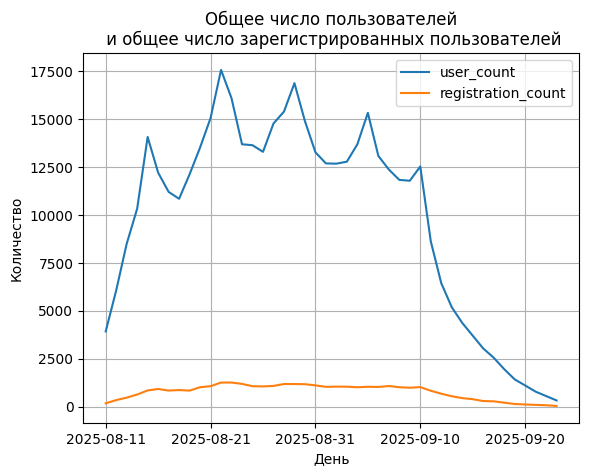

In [7]:
# Строим графики числа уникальных и числа зарегистрированных пользователей

import matplotlib.pyplot as plt

sessions_history_agg.plot.line()

plt.title('Общее число пользователей\n и общее число зарегистрированных пользователей')

plt.xlabel('День')
plt.ylabel('Количество')

plt.grid(True)

plt.legend(loc='upper right')

plt.show()

In [8]:
# Считаем долю зарегистрированных от общего числа пользователей
sessions_history_agg['share'] = sessions_history_agg['registration_count'] / sessions_history_agg['user_count']
sessions_history_agg['share'].head()

session_date
2025-08-11    0.043123
2025-08-12    0.055482
2025-08-13    0.054659
2025-08-14    0.060556
2025-08-15    0.059723
Name: share, dtype: float64

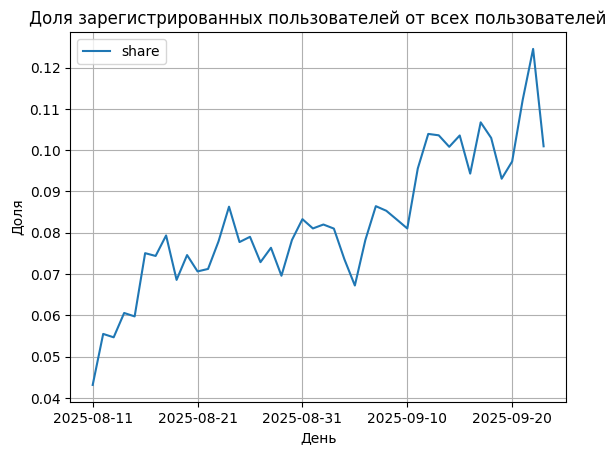

In [9]:
# Строим график динамики доли зарегистрированных пользователей

sessions_history_agg['share'].plot.line()

plt.title('Доля зарегистрированных пользователей от всех пользователей')

plt.xlabel('День')
plt.ylabel('Доля')

plt.grid(True)

plt.legend(loc='upper left')

plt.show()

#### 1.4. Анализ числа просмотренных страниц

Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдём количество сессий для каждого значения количества просмотренных страниц.

- Построим визуализацию.

In [10]:
# Считаем количество сессий для каждого значения количества просмотренных страниц
page_count = sessions_history.groupby('page_counter')['session_id'].count()
page_count.head(10)

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

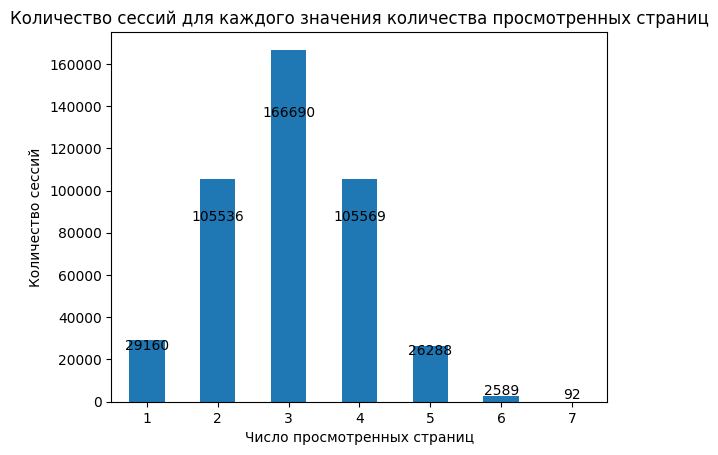

In [11]:
# Строим график

page_count.plot.bar(
    title='Количество сессий для каждого значения количества просмотренных страниц',
    xlabel='Число просмотренных страниц',
    ylabel='Количество сессий',
    rot=0
)

# Подпись значений
for i, v in enumerate(page_count):
    plt.text(i, v * 0.8, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

In [12]:
# Создадим новый столбец с помощью категоризации количества просмотренных страниц

good_sessions = []

for count in sessions_history['page_counter']:
    if count >= 4:
        good_sessions.append(1)
    else:
        good_sessions.append(0)

sessions_history['good_session'] = good_sessions

sessions_history.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0
5,835DD33FC86B3584,3AC48B25BA586DB3,2025-08-15,2025-08-15 18:03:05,2025-08-15,1,0,3,MENA,Android,0
6,AE22C619172A9E28,F1A345355A8981FD,2025-08-15,2025-08-15 23:20:57,2025-08-15,1,0,3,MENA,Android,0
7,2D63C6E7B6D5691B,8EC5B17CA1ED5E10,2025-08-15,2025-08-15 14:45:02,2025-08-15,1,0,5,MENA,PC,1
8,4FFA441542A50124,E99DF62E41ECAB10,2025-08-15,2025-08-15 18:28:23,2025-08-15,1,0,4,CIS,iPhone,1
9,61DCA6C89DA4288D,3F870A71E087CFE6,2025-08-15,2025-08-15 18:58:52,2025-08-15,1,0,5,CIS,Android,1


In [13]:
# Рассчитаем средние значения долей успешных сессий от всех сессий по дням за весь период наблюдения

sessions_history_good_sessions = sessions_history.groupby('session_date').agg(good_count = ('good_session','sum'), sessions_count = ('session_id','count'))

sessions_history_good_sessions['good_share'] = sessions_history_good_sessions['good_count'] / sessions_history_good_sessions['sessions_count']

sessions_history_good_sessions.head()

,good_count,sessions_count,good_share
session_date,,,
2025-08-11,1226,3919,0.312835
2025-08-12,1829,6056,0.302015
2025-08-13,2604,8489,0.306750
2025-08-14,3262,10321,0.316055
2025-08-15,4289,14065,0.304941


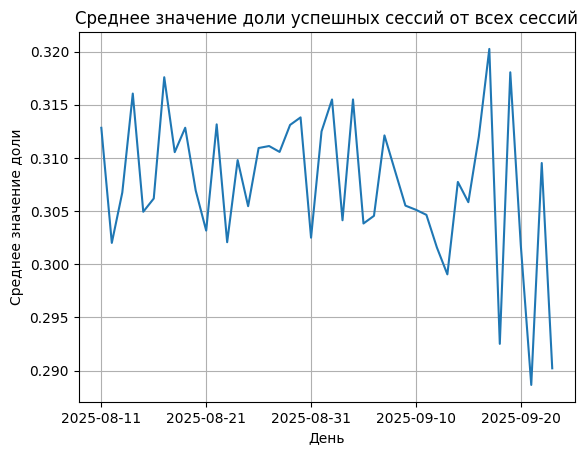

In [14]:
# Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения

sessions_history_good_sessions['good_share'].plot.line()

plt.title('Среднее значение доли успешных сессий от всех сессий')

plt.xlabel('День')
plt.ylabel('Среднее значение доли')

plt.grid(True)

plt.show()

### 2. Подготовка к тесту

Перед проведением теста:

- Сформулируем нулевую и альтернативную гипотезы.

- Определимся с целевой метрикой.

- Рассчитаем необходимый размер выборки.

- Исходя из текущих значений трафика, рассчитаем необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. 

Изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

<b>Ключевая метрика:<b> 

Число просмотренных страниц в приложении (при её росте будет повышаться и Доля зарегистрированных пользователей от всех пользователей). Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

<b>Формулируем гипотезы:<b>

H0: В результате эксперимента с внедрением нового алгоритма рекомендаций среднее число просмотренных страниц (или Доля успешных сессий) в группе В по сравнению с группой А не изменится.

H1: В результате эксперимента с внедрением нового алгоритма рекомендаций среднее число просмотренных страниц (или Доля успешных сессий) в группе В по сравнению с группой А увеличится.

#### 2.2. Расчёт размера выборки

Установим следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

In [1]:
# Рассчитаем необходимый размер выборки

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

Используя данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения, рассчитаем длительность теста.

In [16]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

Нам доступны данные за первые три дня A/B-теста. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем процентную разницу в количестве пользователей в группах A и B.

- Построим визуализацию, на которой будет видно возможное различие двух групп.

In [17]:
# Сохраним файл с данными о сессиях пользователей в датафрейм
sessions_test_part = pd.read_csv('.../sessions_project_test_part.csv')
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [18]:
# Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения

days_count = sessions_test_part['session_date'].nunique()

group_A_per_day = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique() / days_count

group_B_per_day = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique() / days_count

group_A_per_day, group_B_per_day, days_count

(1477.0, 1466.0, 1)

In [19]:
# Рассчитаем процентную разницу в количестве пользователей в группах A и B

P = 100 * ((group_A_per_day - group_B_per_day) / group_A_per_day)

print(f'Процентная разница в количестве пользователей в группах A и B равна {P} процента')

Процентная разница в количестве пользователей в группах A и B равна 0.7447528774542992 процента


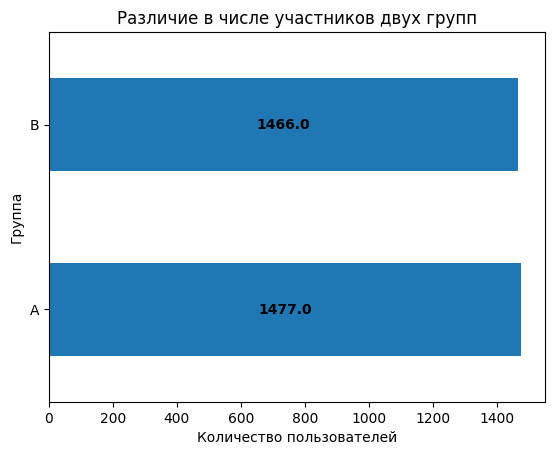

In [20]:
# Построим визуализацию различия в числе участников двух групп

data = {'Группа': ['A', 'B'], 'Количество пользователей': [group_A_per_day, group_B_per_day]}

df = pd.DataFrame(data)

df.plot.barh(x = 'Группа', y = 'Количество пользователей', legend=False)

plt.xlabel('Количество пользователей')
plt.title('Различие в числе участников двух групп')

# Подпись значений
for i, v in enumerate(df['Количество пользователей']):
    plt.text(v / 2, i, str(v), va='center', ha='center', fontweight='bold')

plt.show()

#### 3.2. Проверка пересечений пользователей

Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого убедимся, что никто из пользователей случайно не попал в обе группы одновременно.

In [21]:
# Убедимся, что нет пользователей, которые встречаются одновременно в группах A и B
A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(A) & set(B))
print(intersection)

[]


Пересечений в user_id между группами не нашлось.

#### 3.3. Равномерность разделения пользователей по устройствам

Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам. Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

In [22]:
# Рассчитаем долю каждого типа устройства для пользователей из группы A
devices_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id']. nunique().reset_index()
sum_devices_A = devices_A['user_id'].sum()
devices_A['share'] = devices_A['user_id'] / sum_devices_A
devices_A

,device,user_id,share
0,Android,656,0.444144
1,Mac,156,0.105619
2,PC,369,0.249831
3,iPhone,296,0.200406


In [23]:
devices_A = devices_A.set_index(keys='device')
devices_A

,user_id,share
device,,
Android,656,0.444144
Mac,156,0.105619
PC,369,0.249831
iPhone,296,0.200406


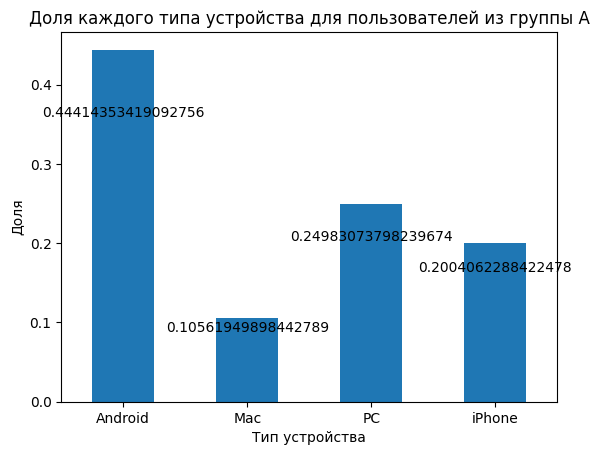

In [24]:
# Построим диаграмму для группы А

devices_A['share'].plot.bar(legend=False, title='Доля каждого типа устройства для пользователей из группы A', 
                   ylabel='Доля', xlabel='Тип устройства', rot=0)

# Подпись значений
for i, v in enumerate(devices_A['share']):
    plt.text(i, v * 0.8, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

In [25]:
# Рассчитаем долю каждого типа устройства для пользователей из группы B
devices_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id']. nunique().reset_index()
sum_devices_B = devices_B['user_id'].sum()
devices_B['share'] = devices_B['user_id'] / sum_devices_B
devices_B

,device,user_id,share
0,Android,668,0.455662
1,Mac,148,0.100955
2,PC,381,0.259891
3,iPhone,269,0.183492


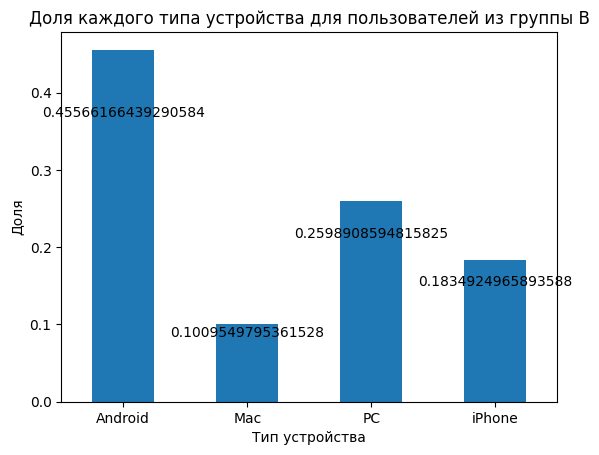

In [26]:
# Построим диаграмму для группы B
devices_B = devices_B.set_index(keys='device')
devices_B['share'].plot.bar(legend=False, title='Доля каждого типа устройства для пользователей из группы B', 
                   ylabel='Доля', xlabel='Тип устройства', rot=0)

# Подпись значений
for i, v in enumerate(devices_B['share']):
    plt.text(i, v * 0.8, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

Теперь убедимся, что пользователи равномерно распределены по регионам. Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [27]:
# Рассчитаем долю каждого региона для пользователей из группы A

regions_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique().reset_index()
sum_regions_A = regions_A['user_id'].sum()
regions_A['share'] = regions_A['user_id'] / sum_regions_A
regions_A

,region,user_id,share
0,CIS,644,0.436019
1,EU,224,0.151659
2,MENA,609,0.412322


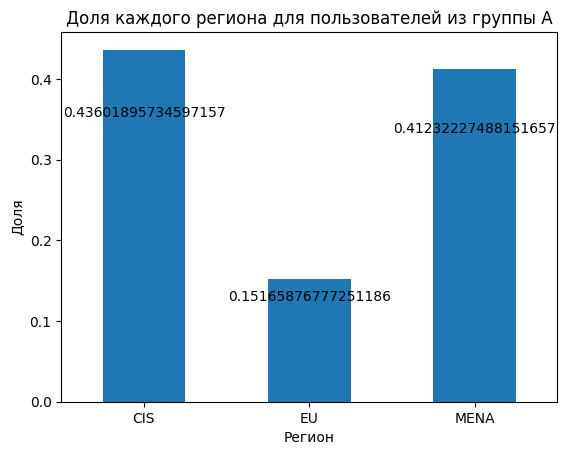

In [28]:
# Построим диаграмму для группы А

regions_A = regions_A.set_index(keys='region')

regions_A['share'].plot.bar(legend=False, title='Доля каждого региона для пользователей из группы A', 
                   ylabel='Доля', xlabel='Регион', rot=0)

# Подпись значений
for i, v in enumerate(regions_A['share']):
    plt.text(i, v * 0.8, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

In [29]:
# Рассчитаем долю каждого региона для пользователей из группы B

regions_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique().reset_index()
sum_regions_B = regions_B['user_id'].sum()
regions_B['share'] = regions_B['user_id'] / sum_regions_B
regions_B

,region,user_id,share
0,CIS,645,0.439973
1,EU,217,0.148022
2,MENA,604,0.412005


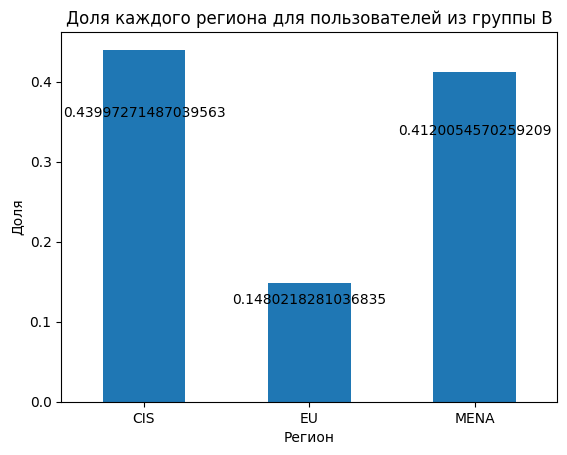

In [30]:
# Построим диаграмму для группы B

regions_B = regions_B.set_index(keys='region')

regions_B['share'].plot.bar(legend=False, title='Доля каждого региона для пользователей из группы B', 
                   ylabel='Доля', xlabel='Регион', rot=0)

# Подпись значений
for i, v in enumerate(regions_B['share']):
    plt.text(i, v * 0.8, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

#### 3.5. Вывод после проверки A/B-теста

<b>После проверки A/B-теста обнаружено:<b>

- Процентная разница в количестве пользователей в группах A и B незначительная и равна 0.7447528774542992 процента.
- Пересечений в user_id между группами A и B не нашлось. Выборки являются независимыми.
- Распределение пользователей в группах A и B по устройствам и регионам равномерное.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создаем дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [31]:
# Cохраним в датафрейм файл с данными о сессиях пользователей
sessions_test = pd.read_csv('.../sessions_project_test.csv')
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [32]:
# Cоздадим дополнительный столбец c помощью категоризации числа просмотренных страниц

good_sessions_test = []

for count in sessions_test['page_counter']:
    if count >= 4:
        good_sessions_test.append(1)
    else:
        good_sessions_test.append(0)

sessions_test['good_session'] = good_sessions_test

sessions_test.head(10)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
5,31F7A42B32103403,E9B64B779C3348ED,2025-10-20,2025-10-20 17:09:41,2025-10-19,2,0,2,CIS,PC,B,0
6,87C09E3E3B334959,FECFF83C13DC9364,2025-10-22,2025-10-22 23:51:42,2025-10-20,3,0,4,CIS,iPhone,B,1
7,457F2674E87EF6E7,14F71C18BE2CEC08,2025-10-19,2025-10-19 11:49:11,2025-10-19,1,0,3,MENA,Mac,A,0
8,57F342451921D207,76EFA055599ADE3C,2025-10-19,2025-10-19 18:47:43,2025-10-19,1,0,3,CIS,PC,A,0
9,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B,0


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- Выведем значение p-value и интерпретируем его.

In [33]:
# Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп
sessions_A = sessions_test[sessions_test['test_group'] == 'A'].groupby('session_date')['session_id'].nunique()
sessions_B = sessions_test[sessions_test['test_group'] == 'B'].groupby('session_date')['session_id'].nunique()
sessions_A, sessions_B

(session_date
 2025-10-14    1502
 2025-10-15    2235
 2025-10-16    3280
 2025-10-17    4089
 2025-10-18    5013
 2025-10-19    6535
 2025-10-20    5837
 2025-10-21    3927
 2025-10-22    3083
 2025-10-23    2470
 2025-10-24    2090
 2025-10-25    1897
 2025-10-26    1669
 2025-10-27    1454
 2025-10-28    1279
 2025-10-29    1068
 2025-10-30     887
 2025-10-31     644
 2025-11-01     434
 2025-11-02     158
 Name: session_id, dtype: int64,
 session_date
 2025-10-14    1628
 2025-10-15    2283
 2025-10-16    3241
 2025-10-17    4054
 2025-10-18    5059
 2025-10-19    6779
 2025-10-20    6089
 2025-10-21    3981
 2025-10-22    3111
 2025-10-23    2548
 2025-10-24    2068
 2025-10-25    1814
 2025-10-26    1692
 2025-10-27    1517
 2025-10-28    1289
 2025-10-29    1131
 2025-10-30     876
 2025-10-31     669
 2025-11-01     465
 2025-11-02     160
 Name: session_id, dtype: int64)

In [34]:
# Рассчитаем фактическое количество дней эксперимента

sessions_A.shape[0], sessions_B.shape[0]

(20, 20)

In [35]:
# Проведём статистический тест для проверки, 
# что количество уникальных дневных сессий в двух выборках не различается или различия 
# не являются статистически значимыми

from scipy.stats import mannwhitneyu

alpha = 0.05

results_sessions = mannwhitneyu(
    sessions_A,
    sessions_B)

# печатаем результаты
print('p-value:', results_sessions.pvalue)

if (results_sessions.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергать нулевую гипотезу")

p-value: 0.8817307917391243
Нет оснований отвергать нулевую гипотезу


<b>Вывод:<b> 

В результате статистического теста Манна-Уитни нулевая гипотеза о равенстве средних двух выборок не была отвергнута. Следовательно количество уникальных дневных сессий в двух выборках не различается или различия не являются статистически значимыми.

#### 4.3. Сравнение доли успешных сессий

Мы убедились, что количество сессий в обеих выборках не различалось, теперь можно переходить к анализу ключевой метрики — доли успешных сессий.

Используя созданный столбец `good_session`, рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [36]:
# Рассчитаем долю успешных сессий для выборок A и B

good_sessions = sessions_test.groupby('test_group').agg({'good_session': 'sum', 'session_id': 'count'}).reset_index()

good_sessions['good_share'] = good_sessions['good_session'] / good_sessions['session_id']

good_sessions

,test_group,good_session,session_id,good_share
0,A,15248,49551,0.307723
1,B,16059,50454,0.318290


In [37]:
# Рассчитаем разницу в показателе Доля успешных сессий между группами A и B

diff = good_sessions.loc[0, 'good_share'] - good_sessions.loc[1, 'good_share']
print(f'Доля успешных сессий между группами A и B различается на {diff * 100} процентов.')

Доля успешных сессий между группами A и B различается на -1.0566571724179463 процентов.


<b>Вывод:<b> 

Доля успешных сессий в группе В выше на 1,1%.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведем на экран полученное значение p-value и выводы о статистической значимости. 

Уровень значимости в эксперименте был выбран на уровне 0.05.

In [38]:
# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

n_a = good_sessions.loc[0, 'session_id']
n_b = good_sessions.loc[1, 'session_id']

m_a = good_sessions.loc[0, 'good_session']
m_b = good_sessions.loc[1, 'good_session']

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger')

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!


<b>Вывод:<b> 

В результате Z-теста пропорций нулевая гипотеза была отвергнута. Следовательно изменение показателя успешных сессий в двух выборках статистически значимо - в тестовой группе В показатель выше. 

#### 4.5. Выводы по результатам A/B-эксперимента


- В рамках проекта были рассчитаны необходимые параметры для проведения А/В-теста: необходимый размер выборки для каждой группы составил 41040 пользователей, рассчитанная длительность теста составила 9 дней.

- В начале теста был проведён мониторинг: проведена проверка распределения пользователей по группам: процентная разница в количестве пользователей в группах A и B незначительна и составила примерно 0.74 процента; проверка пересечений пользователей между группами - их не было обнаружено; распределение пользователей в группах A и B по категориальным признакам (устройствам и регионам) оказалось равномерное.

- Фактически тест длился 20 дней. Таким образом, данных для исследования было собрано достаточно. 

- В результате анализа результатов эксперимента оказалось, что в тестовой группе значение ключевой  метрики выше - и это изменение показателя статистически значимо.

- Значение pvalue получилось 0.0001574739988036123, что значительно ниже выбранного уровня значимости (0.05). То есть вероятность того, что обнаруженные изменения ключевой метрики случайны, а не обусловлены внедрённым изменением, близка к нулю. 

- В результате проведённого A/B-эксперимента можно утверждать, что предпосылки внедрять новый алгоритм рекомендаций есть и обоснованы изученными данными.